#### Student Pass Prediction

X_train_scaled:
    hours_studied  attendance
0        0.000000    0.000000
1        0.166667    0.178571
2        0.333333    0.285714
3        0.333333    0.535714
4        0.500000    0.357143
5        0.500000    0.714286
6        0.666667    0.428571
7        0.666667    0.785714
8        0.833333    0.535714
9        0.833333    0.892857
10       1.000000    0.642857
11       1.000000    1.000000
Logistic Regression Model Output (z):
0    -0.500000
1    -0.323810
2    -0.204762
3    -0.004762
4    -0.114286
5     0.171429
6    -0.023810
7     0.261905
8     0.095238
9     0.380952
10    0.214286
11    0.500000
dtype: float64
y_pred:

0     0.377541
1     0.419748
2     0.448988
3     0.498810
4     0.471460
5     0.542752
6     0.494048
7     0.565104
8     0.523792
9     0.594103
10    0.553367
11    0.622459
dtype: float64
Predicted: Fail
Predicted: Fail
Predicted: Fail
Predicted: Fail
Predicted: Fail
Predicted: Pass
Predicted: Fail
Predicted: Pass
Predicted: Pass
Predicted: Pa

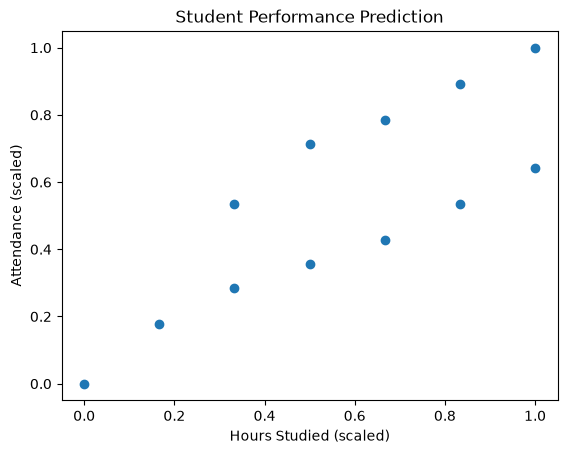

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('student_data.csv')
X = df[["hours_studied", "attendance"]]
y = df["passed"]

X_train = X.iloc[:12]
y_train = y.iloc[:12]

X_test = X.iloc[12:]
y_test = y.iloc[12:]

# feature scaling (true min-max normalization: (X - min) / (max - min))
hours_min = X_train["hours_studied"].min()
hours_max = X_train["hours_studied"].max()
attendance_min = X_train["attendance"].min()
attendance_max = X_train["attendance"].max()

X_train_scaled = X_train.copy()
X_train_scaled["hours_studied"] = (
    (X_train["hours_studied"] - hours_min) / (hours_max - hours_min)
)
X_train_scaled["attendance"] = (
    (X_train["attendance"] - attendance_min) / (attendance_max - attendance_min)
)

print("X_train_scaled:")
print(X_train_scaled)

w1 = 0.2
w2 = 0.8
b = -0.5  # fixed from 0.5 -> -0.5 so z can actually go negative

# calculate z (z = w1 * hours_studied + w2 * attendance + b)
z = w1 * X_train_scaled["hours_studied"] + w2 * X_train_scaled["attendance"] + b
print("Logistic Regression Model Output (z):")
print(z)

# calculate the sigmoid of z
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

y_pred = sigmoid(z)
print("y_pred:\n")
print(y_pred)

# Decision Boundary: If y_pred >= 0.5, predict 1 (pass), else predict 0 (fail)
for i in y_pred:
    if i >= 0.50:
        print("Predicted: Pass")
    else:
        print("Predicted: Fail")

plt.plot(X_train_scaled["hours_studied"], X_train_scaled["attendance"], 'o')
plt.xlabel("Hours Studied (scaled)")
plt.ylabel("Attendance (scaled)")
plt.title("Student Performance Prediction")
plt.show()

w_final: [ 4.40793481 15.85061889]
b_final: -16.836590939250616


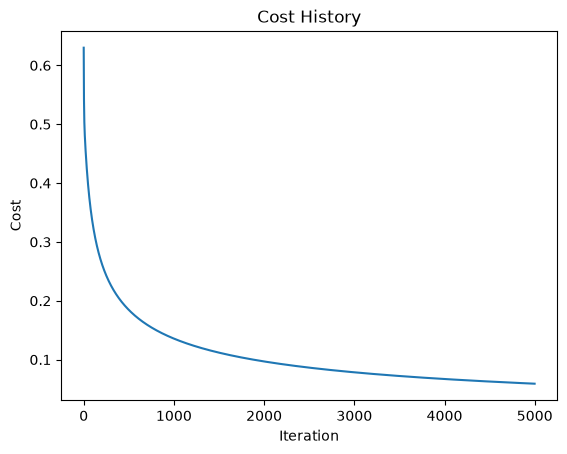

Final cost: 0.05905402638487745
First cost: 0.6300377293036837


In [27]:
#Gradient Descent Implementation
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_cost(X, y, w, b):
    m = X.shape[0]
    z = X @ w + b
    f = sigmoid(z)
    eps = 1e-15
    cost = -np.mean(y * np.log(f + eps) + (1 - y) * np.log(1 - f + eps))
    return cost

def compute_gradient(X, y, w, b):
    m = X.shape[0]
    z = X @ w + b
    f = sigmoid(z)
    error = f - y
    dj_dw = (X.T @ error) / m
    dj_db = np.sum(error) / m
    return dj_dw, dj_db
def gradient_descent(X, y, w_in, b_in, alpha, iterations, compute_cost, compute_gradient):
    w = w_in.copy()
    b = b_in
    cost_history = []

    for i in range(iterations):
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        cost_history.append(compute_cost(X, y, w, b))

    return w, b, cost_history
X_train_arr = X_train_scaled.values
y_train_arr = y_train.values.astype(float)
w_init = np.zeros(X_train_arr.shape[1])
b_init = 0.0
alpha = 0.5
iterations = 5000

w_final, b_final, cost_history = gradient_descent(
    X_train_arr, y_train_arr, w_init, b_init, alpha, iterations,
    compute_cost, compute_gradient
)

print("w_final:", w_final)
print("b_final:", b_final)  

plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost History")
plt.show()

print("Final cost:", cost_history[-1])
print("First cost:", cost_history[0])

In [28]:
z_learned = X_train_arr @ w_final + b_final
y_pred_learned = sigmoid(z_learned)
predicted_labels = (y_pred_learned >= 0.5).astype(int)
accuracy = (predicted_labels == y_train_arr).mean()
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 100.00%


In [29]:
X_test_scaled = X_test.copy()
X_test_scaled["hours_studied"] = (
    (X_test["hours_studied"] - hours_min) / (hours_max - hours_min)
)
X_test_scaled["attendance"] = (
    (X_test["attendance"] - attendance_min) / (attendance_max - attendance_min)
)
print(X_test_scaled)

    hours_studied  attendance
12       1.166667    0.714286
13       1.166667    0.357143
14       1.333333    0.785714
15       1.333333    1.071429
16       1.333333    0.535714
17       1.500000    0.857143
18       1.500000    1.250000
19       1.666667    0.928571
20       1.666667    0.285714
21       1.833333    1.000000
22       1.833333    1.428571
23       2.000000    1.071429
24       2.000000    0.642857
25       2.166667    1.142857
26       2.166667    0.178571
27       2.333333    1.214286
28       2.333333    1.500000
29       2.500000    1.285714
30       2.666667    1.357143
31       2.666667    1.607143
32       0.666667    1.250000
33       0.333333    1.428571
34       1.666667    0.000000
35       1.000000    1.607143


In [30]:
X_test_arr = X_test_scaled.values
y_test_arr = y_test.values.astype(float)

z_test = X_test_arr @ w_final + b_final
y_pred_test = sigmoid(z_test)
predicted_test_labels = (y_pred_test >= 0.5).astype(int)

test_accuracy = (predicted_test_labels == y_test_arr).mean()
print(f"Test Accuracy: {test_accuracy:.2%}")

Test Accuracy: 91.67%


In [31]:
# predict from the user's input
import numpy as np
def predict(user_input):
    user_input_scaled = np.array([
        (user_input[0] - hours_min) / (hours_max - hours_min),
        (user_input[1] - attendance_min) / (attendance_max - attendance_min)
    ])
    z_user = user_input_scaled @ w_final + b_final
    y_pred_user = sigmoid(z_user)
    return "Pass" if y_pred_user >= 0.5 else "Fail"
input_hours = float(input("Enter hours studied: "))
input_attendance = float(input("Enter attendance: "))
user_input = [input_hours, input_attendance]
result = predict(user_input)
print(f"The hours studied:{input_hours}")
print(f"The attendance:{input_attendance}")
print(f"The prediction is: {result}")

The hours studied:6.0
The attendance:45.0
The prediction is: Fail
